In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:
df=pd.read_csv(r'/Users/anirudhiyer/cicids-mlops/data/raw/wednesday.csv')

In [83]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692703 entries, 0 to 692702
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             692703 non-null  int64  
 1    Flow Duration                692703 non-null  int64  
 2    Total Fwd Packets            692703 non-null  int64  
 3    Total Backward Packets       692703 non-null  int64  
 4   Total Length of Fwd Packets   692703 non-null  int64  
 5    Total Length of Bwd Packets  692703 non-null  int64  
 6    Fwd Packet Length Max        692703 non-null  int64  
 7    Fwd Packet Length Min        692703 non-null  int64  
 8    Fwd Packet Length Mean       692703 non-null  float64
 9    Fwd Packet Length Std        692703 non-null  float64
 10  Bwd Packet Length Max         692703 non-null  int64  
 11   Bwd Packet Length Min        692703 non-null  int64  
 12   Bwd Packet Length Mean       692703 non-nul

In [85]:
df[' Label']

0         BENIGN
1         BENIGN
2         BENIGN
3         BENIGN
4         BENIGN
           ...  
692698    BENIGN
692699    BENIGN
692700    BENIGN
692701    BENIGN
692702    BENIGN
Name:  Label, Length: 692703, dtype: object

In [86]:

df[' Label'] = df[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

In [87]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0


In [88]:
df.duplicated().sum()

np.int64(81909)

In [89]:
df=df.drop_duplicates()

In [90]:
X=df.drop(columns=[' Label'])
y=df[' Label']

In [91]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [92]:
import numpy as np

print("Inf values:", np.isinf(X_train).sum().sum())
print("NaN values:", np.isnan(X_train).sum().sum())
print("Max value:", np.max(X_train))

Inf values: 432
NaN values: 46
Max value: inf


In [93]:
df.isnull().sum()

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64

In [94]:
np.isnan(df).sum()

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64

In [95]:
# Convert everything to numeric (VERY IMPORTANT)
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# Replace inf
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop NaN rows (align y also)
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]

In [96]:
X_train = X_train.clip(-1e6, 1e6)
X_test = X_test.clip(-1e6, 1e6)

In [97]:
print(X_train.duplicated().sum())
print(X_test.duplicated().sum())

37
3


In [98]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [99]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=150,min_samples_leaf=5,min_samples_split=5,max_depth=15)

In [100]:
rf.fit(X_train,y_train)


,n_estimators,150
,criterion,'gini'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [101]:
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score

y_pred=rf.predict(X_test)

In [102]:
print(accuracy_score(y_pred,y_test)*100)
print(precision_score(y_pred,y_test)*100)
print(recall_score(y_pred,y_test)*100)
print(f1_score(y_pred,y_test)*100)

99.92464945616564
99.85015243114762
99.91210382089861
99.88111851966714


<Axes: xlabel=' Label', ylabel='count'>

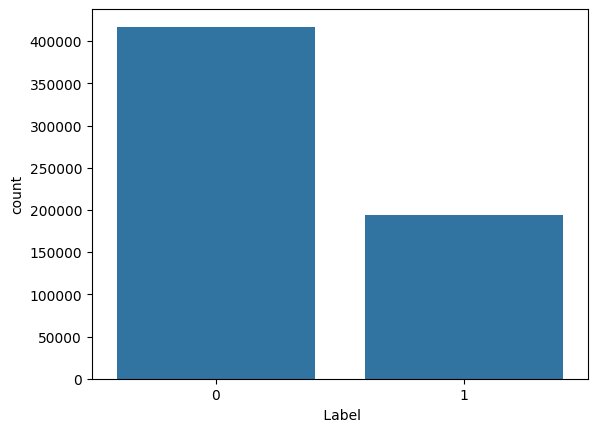

In [103]:
sns.countplot(x=df[' Label'])

In [72]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [104]:
import xgboost as xgb

In [105]:
from xgboost.sklearn import XGBClassifier

In [114]:
xgb = XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss'
        )

In [115]:
xgb.fit(X_train,y_train)

/Users/anirudhiyer/cicids-mlops/venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [12:28:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [116]:
y_pred=xgb.predict(X_test)

In [117]:
print(accuracy_score(y_pred,y_test)*100)
print(precision_score(y_pred,y_test)*100)
print(recall_score(y_pred,y_test)*100)
print(f1_score(y_pred,y_test)*100)

99.97624819813917
99.97933136981347
99.94576306206255
99.96254439780434


In [118]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

 Label
0    0.682532
1    0.317468
Name: proportion, dtype: float64
 Label
0    0.682987
1    0.317013
Name: proportion, dtype: float64


In [119]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[83369    21]
 [    8 38698]]


In [120]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     83390
           1       1.00      1.00      1.00     38706

    accuracy                           1.00    122096
   macro avg       1.00      1.00      1.00    122096
weighted avg       1.00      1.00      1.00    122096



In [121]:
import numpy as np

y_train_shuffled = np.random.permutation(y_train)

xgb.fit(X_train, y_train_shuffled)
print(xgb.score(X_test, y_test))

/Users/anirudhiyer/cicids-mlops/venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [12:28:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


0.6828315423928711
